# 03 — Business Deep Dive

In notebook 02 we described *what* the data looks like. This notebook asks *why*,
and stress-tests the headline findings before turning them into business advice.

Each section follows the same investigative pattern:

1. **Hypothesis** — a clear, falsifiable claim about what is driving a result.
2. **Evidence** — the metrics and visualization used to test that claim.
3. **Conclusion** — what the evidence supports, stated in business terms.

The goal is not to confirm the obvious, but to separate real drivers from
surface-level correlations — the difference between "Electronics earns the most"
and "Electronics earns the most *because* of price, not volume."

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.plots import style_axis

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/processed/retail_sales_cleaned.csv', parse_dates = ['order_date'])
fig_path = "../reports/figures/"

## Business Question 1 — Why does Electronics dominate revenue?

Initial analysis showed Electronics contributes disproportionately to total
revenue. Three competing explanations exist:

- Electronics products are simply more expensive (price driver).
- Customers buy more Electronics items per order (basket driver).
- Electronics receives more orders (demand driver).

**Hypothesis:** dominance is primarily a *price* effect, reinforced by strong
order volume — not by larger baskets per order.

**Evidence:** per-category profile of average unit price, average quantity,
and order count shown as a normalized category-vs-metric
heatmap so each category's "signature" is visible at a glance.

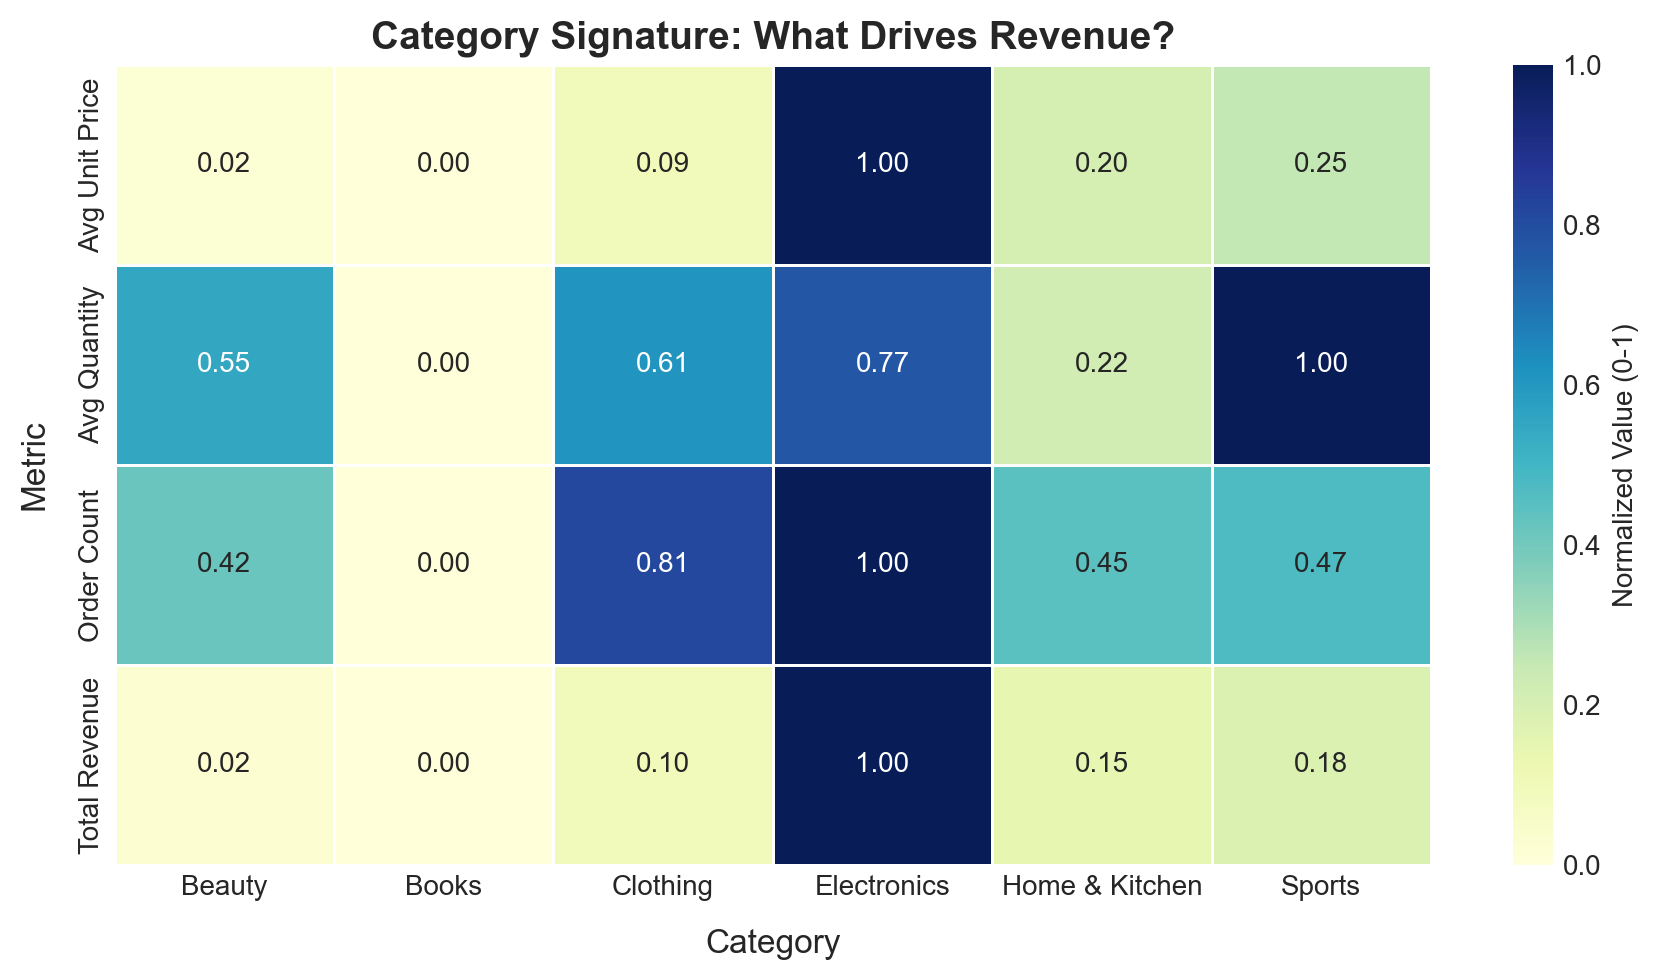

In [8]:
heat_map_data = df.groupby('category').agg(
    avg_unit_price = ('unit_price', 'mean'), avg_quantity = ('quantity', 'mean'), 
    order_count = ('order_id', 'count'), total_revenue = ('total_price', 'sum'))

norm_heat_map_data = (heat_map_data - heat_map_data.min()) / (heat_map_data.max() - heat_map_data.min())
norm_heat_map_data = norm_heat_map_data.rename(columns = {'avg_unit_price' : 'Avg Unit Price', 
        'avg_quantity' : 'Avg Quantity', 'order_count' : 'Order Count', 'total_revenue' : 'Total Revenue'})
norm_heat_map_data = norm_heat_map_data.T

fig, ax = plt.subplots(figsize = (9, 5), dpi = 200)

sns.heatmap(norm_heat_map_data, annot = True, fmt = ".2f", cmap = "YlGnBu", linewidth = 0.5,
            cbar_kws = {'label' : 'Normalized Value (0-1)'}, ax = ax)
style_axis(ax, 'Category', 'Metric', 'Category Signature: What Drives Revenue?')
ax.xaxis.labelpad = 10
ax.yaxis.labelpad = 10
ax.title.set_y(1.05)

plt.tight_layout()
plt.savefig(fig_path + 'q1_category_signature_heatmap.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**Conclusion:** Electronics leads every category in average unit price while
keeping comparable quantity per order, and it also attracts the most orders. Its
revenue is therefore explained by *high transaction value combined with strong
demand*, not by larger baskets. 

---

## Business Question 2 — Is West really the best-performing region?

EDA identified West as the highest-revenue region. However, high revenue may result
from either higher spending per transaction or simply serving more customers.

**Hypothesis:** West's revenue leadership is driven by customer volume rather than
larger transactions.

**Evidence:** Decompose regional performance into three components:
customer count, orders per customer, and average order value.

,region,customer_count,order_count,avg_order_value,orders_per_customer
0,Central,616,870,349.774943,1.412338
1,East,630,896,375.011897,1.422222
2,North,717,1072,353.648535,1.495119
3,South,686,1051,384.862550,1.532070
4,West,723,1111,369.032412,1.536653


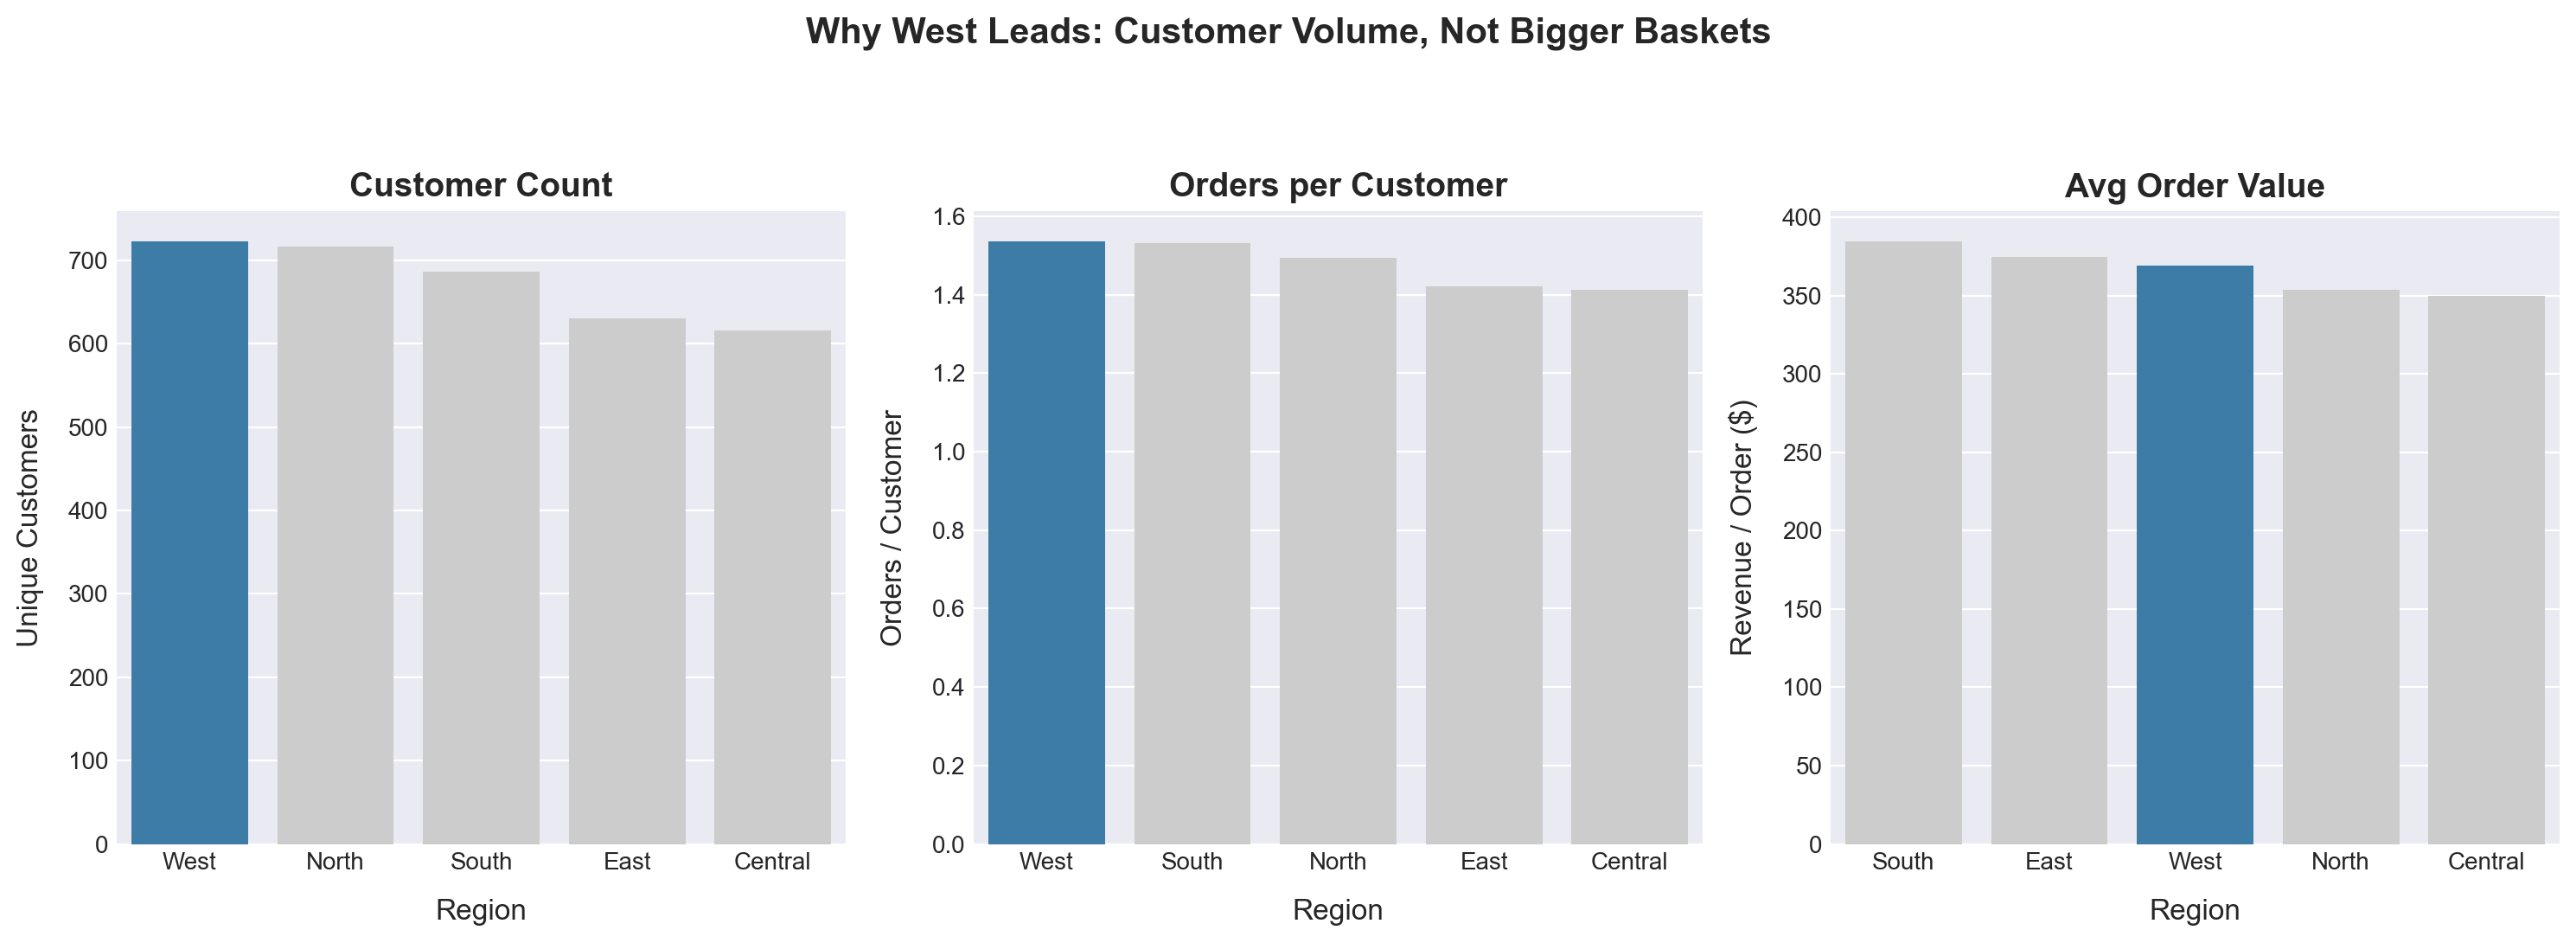

In [17]:
region_data = df.groupby('region', as_index = False).agg(customer_count = ('customer_id', 'nunique'),
                        order_count = ('order_id', 'count'), avg_order_value = ('total_price', 'mean'))
region_data['orders_per_customer'] = region_data['order_count'] / region_data['customer_count']
display(region_data)

palette = {r: ('#2c7fb8' if r == 'West' else '#cccccc') for r in region_data['region']}

fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (15, 5), dpi = 200) 

sns.barplot(data = region_data.sort_values('customer_count', ascending = False), x = 'region', y = 'customer_count', 
            ax = ax[0], hue = 'region', legend = False, palette = palette)
style_axis(ax[0], 'Region', 'Unique Customers', 'Customer Count')

sns.barplot(data = region_data.sort_values('orders_per_customer', ascending = False), x = 'region',
             y = 'orders_per_customer', ax = ax[1], hue = 'region', legend = False, palette = palette)
style_axis(ax[1], 'Region', 'Orders / Customer', 'Orders per Customer')

sns.barplot(data = region_data.sort_values('avg_order_value', ascending = False), x = 'region',
             y = 'avg_order_value', ax = ax[2], hue = 'region', legend = False, palette = palette)
style_axis(ax[2], 'Region', 'Revenue / Order ($)', 'Avg Order Value')

for sub_ax in ax:
    sub_ax.xaxis.labelpad = 10
    sub_ax.yaxis.labelpad = 10
    sub_ax.title.set_y(1.05)

plt.suptitle("Why West Leads: Customer Volume, Not Bigger Baskets", fontsize = 15, fontweight = 'bold', y = 1.08)
plt.tight_layout()
plt.savefig(fig_path + 'q2_region_decomposition.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**Conclusion:** West’s revenue leadership is primarily driven by its *larger customer base*, while purchase frequency is only slightly higher than in other regions. Average order value remains comparable—and is even exceeded by the South—indicating that West succeeds by attracting more customers rather than generating higher-value transactions. Future revenue growth in lower-performing regions should therefore prioritize *customer acquisition and retention* over increasing basket size.

--- 

## Business Question 3 — Do discounts improve customer satisfaction?

Aggregate analysis suggested a positive relationship between discount level and
customer rating. However, an overall trend may simply reflect differences in
customer or product composition rather than a genuine pricing effect.

**Hypothesis:** the positive discount-rating relationship is robust and holds
within segments, not just in aggregate.

**Evidence:** average rating by discount bucket, plotted as three lines —
Overall, Electronics, and West — to check whether the trend survives
segmentation.

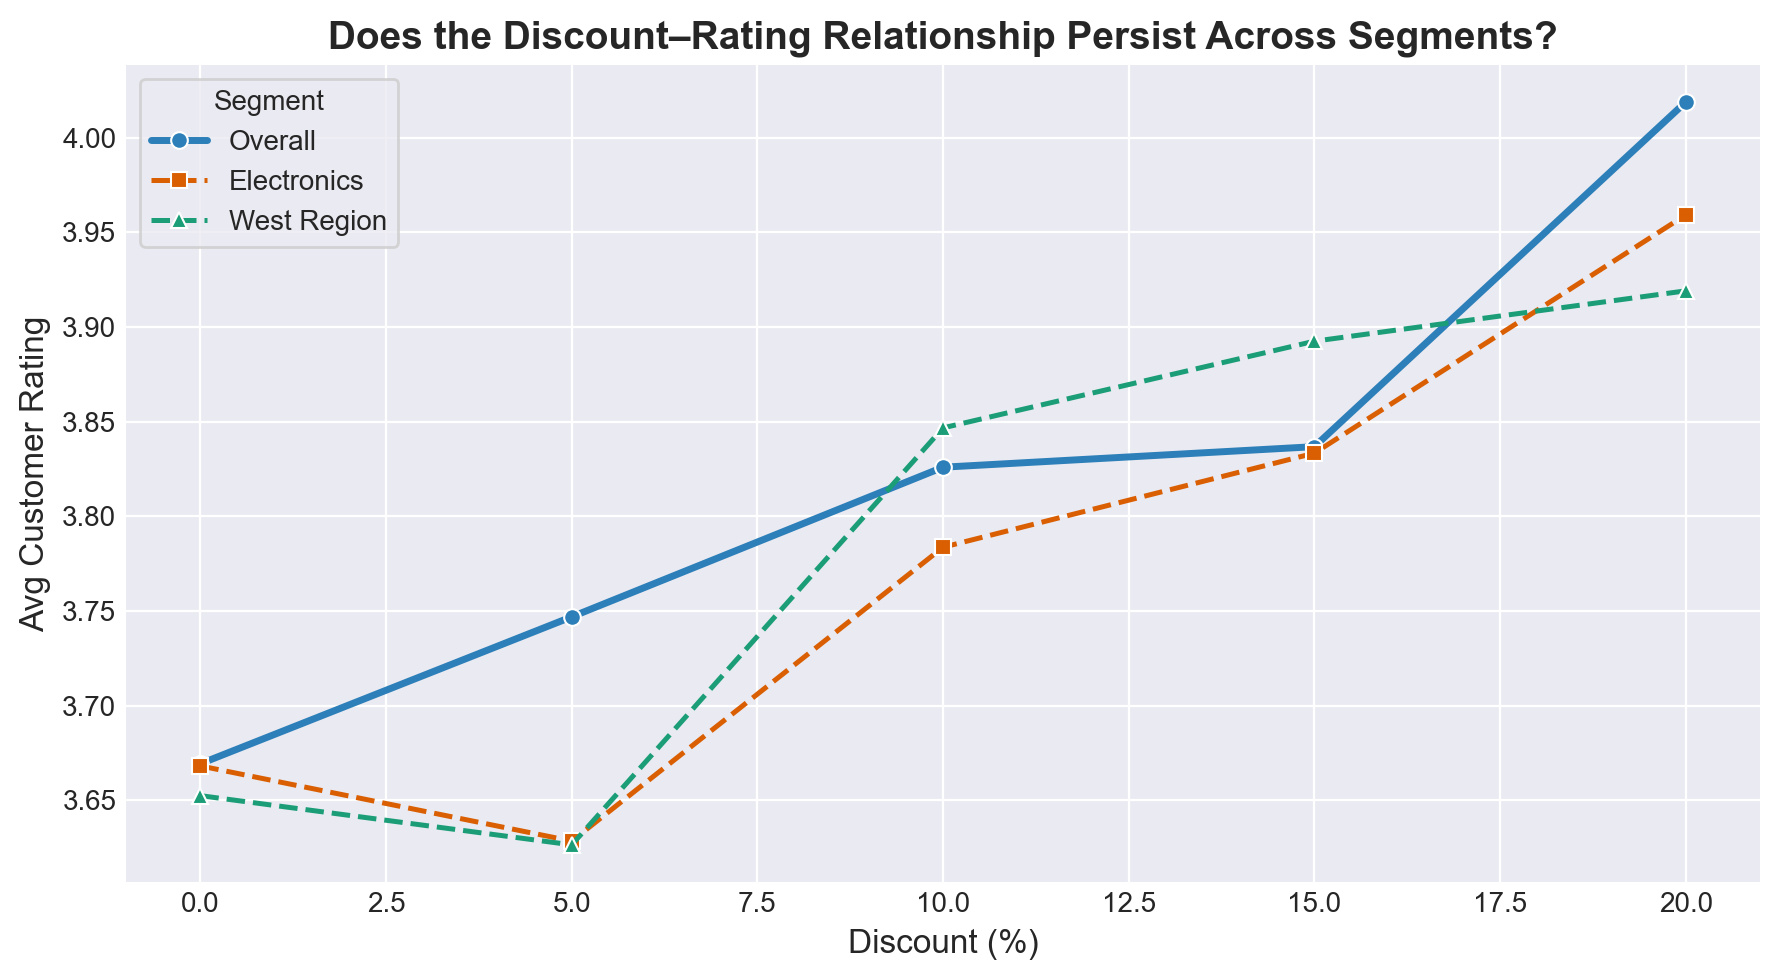

In [27]:
discount_data = df.groupby('discount_pct', as_index = False).agg(
    avg_customer_rating = ('customer_rating', 'mean')).sort_values('discount_pct')

discount_category_data = df[df['category'] == 'Electronics'].groupby('discount_pct', as_index = False).agg(
    avg_customer_rating = ('customer_rating','mean')).sort_values('discount_pct')

discount_region_data = df[df['region'] == 'West'].groupby('discount_pct', as_index = False).agg(
    avg_customer_rating = ('customer_rating', 'mean')).sort_values('discount_pct')


fig, ax = plt.subplots(figsize = (9, 5), dpi = 200)

sns.lineplot(data = discount_data, x = 'discount_pct', y = 'avg_customer_rating', ax = ax, 
             label = "Overall", color = "#2c7fb8", linewidth = 2.5, marker = 'o')

sns.lineplot(data = discount_category_data, x = 'discount_pct', y = 'avg_customer_rating', ax = ax,
             label = "Electronics", color = "#d95f02", linewidth = 1.8, linestyle = '--', marker = 's')

sns.lineplot(data = discount_region_data, x = 'discount_pct', y = 'avg_customer_rating', ax = ax, 
             label = 'West Region', color = "#1b9e77", linewidth = 1.8, linestyle = '--', marker = '^')

style_axis(ax, 'Discount (%)', 'Avg Customer Rating', "Does the Discount–Rating Relationship Persist Across Segments?")
ax.title.set_y(1.02)
ax.legend(title = 'Segment', frameon = True)

plt.tight_layout()
plt.savefig(fig_path + 'q3_discount_vs_rating.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**Conclusion:** The positive relationship between discount level and customer
ratings persists across the overall dataset as well as within the Electronics
category and the West region. Although the increase is not perfectly monotonic,
customers consistently report higher average ratings at larger discount levels.
This suggests the observed association is robust across key business segments
rather than being driven by the overall data composition.

--- 

## Business Question 4 — Is the company's strongest category diversified?

Electronics was identified as the company's primary revenue driver. The next
question is whether that success is distributed across multiple products or
depends heavily on a few flagship items.

**Hypothesis:** Electronics revenue is concentrated in a small number of
high-performing products, creating product concentration risk.

**Evidence:** Compare total revenue generated by each electronic product and
measure how much of the company's total revenue is contributed by the leading
products.

In [29]:
electronic_category_data = df[df['category'] == 'Electronics'].groupby('product', as_index = False).agg(
    total_revenue = ('total_price', 'sum')).sort_values('total_revenue', ascending = False).reset_index(drop = True)
display(electronic_category_data)

print(f"Top five products contribute {electronic_category_data.loc[:5, 'total_revenue'].sum() * 100 / df['total_price'].sum():.1f}% of total company revenue")

,product,total_revenue
0,Laptop,498131.86
1,Smartphone,325882.74
2,Tablet,186874.04
3,Smartwatch,106473.64
4,Speaker,43675.43
5,Headphones,28312.18


Top five products contribute 64.9% of total company revenue


**Conclusion:** Electronics is driven primarily by three flagship products
(Laptop, Smartphone, and Tablet), while the remaining products contribute
relatively little revenue. Together, the top five electronic products account
for nearly 65% of total company revenue, indicating that the business depends
heavily on a small portion of its product portfolio.

---

## Business Question 5 — Who drives company revenue?

Individual customer IDs are useful operationally, but business strategy is driven
by customer segments rather than specific people. We therefore classify customers
by lifetime spending and compare their share of the customer base with their share
of total revenue.

**Hypothesis:** A relatively small group of high-value customers contributes a
disproportionately large share of company revenue.

**Evidence:** Compare customer composition with revenue composition using two
side-by-side pie charts: one showing the percentage of customers in each segment
(VIP, Regular, Occasional), and the other showing the percentage of total revenue
generated by each segment.

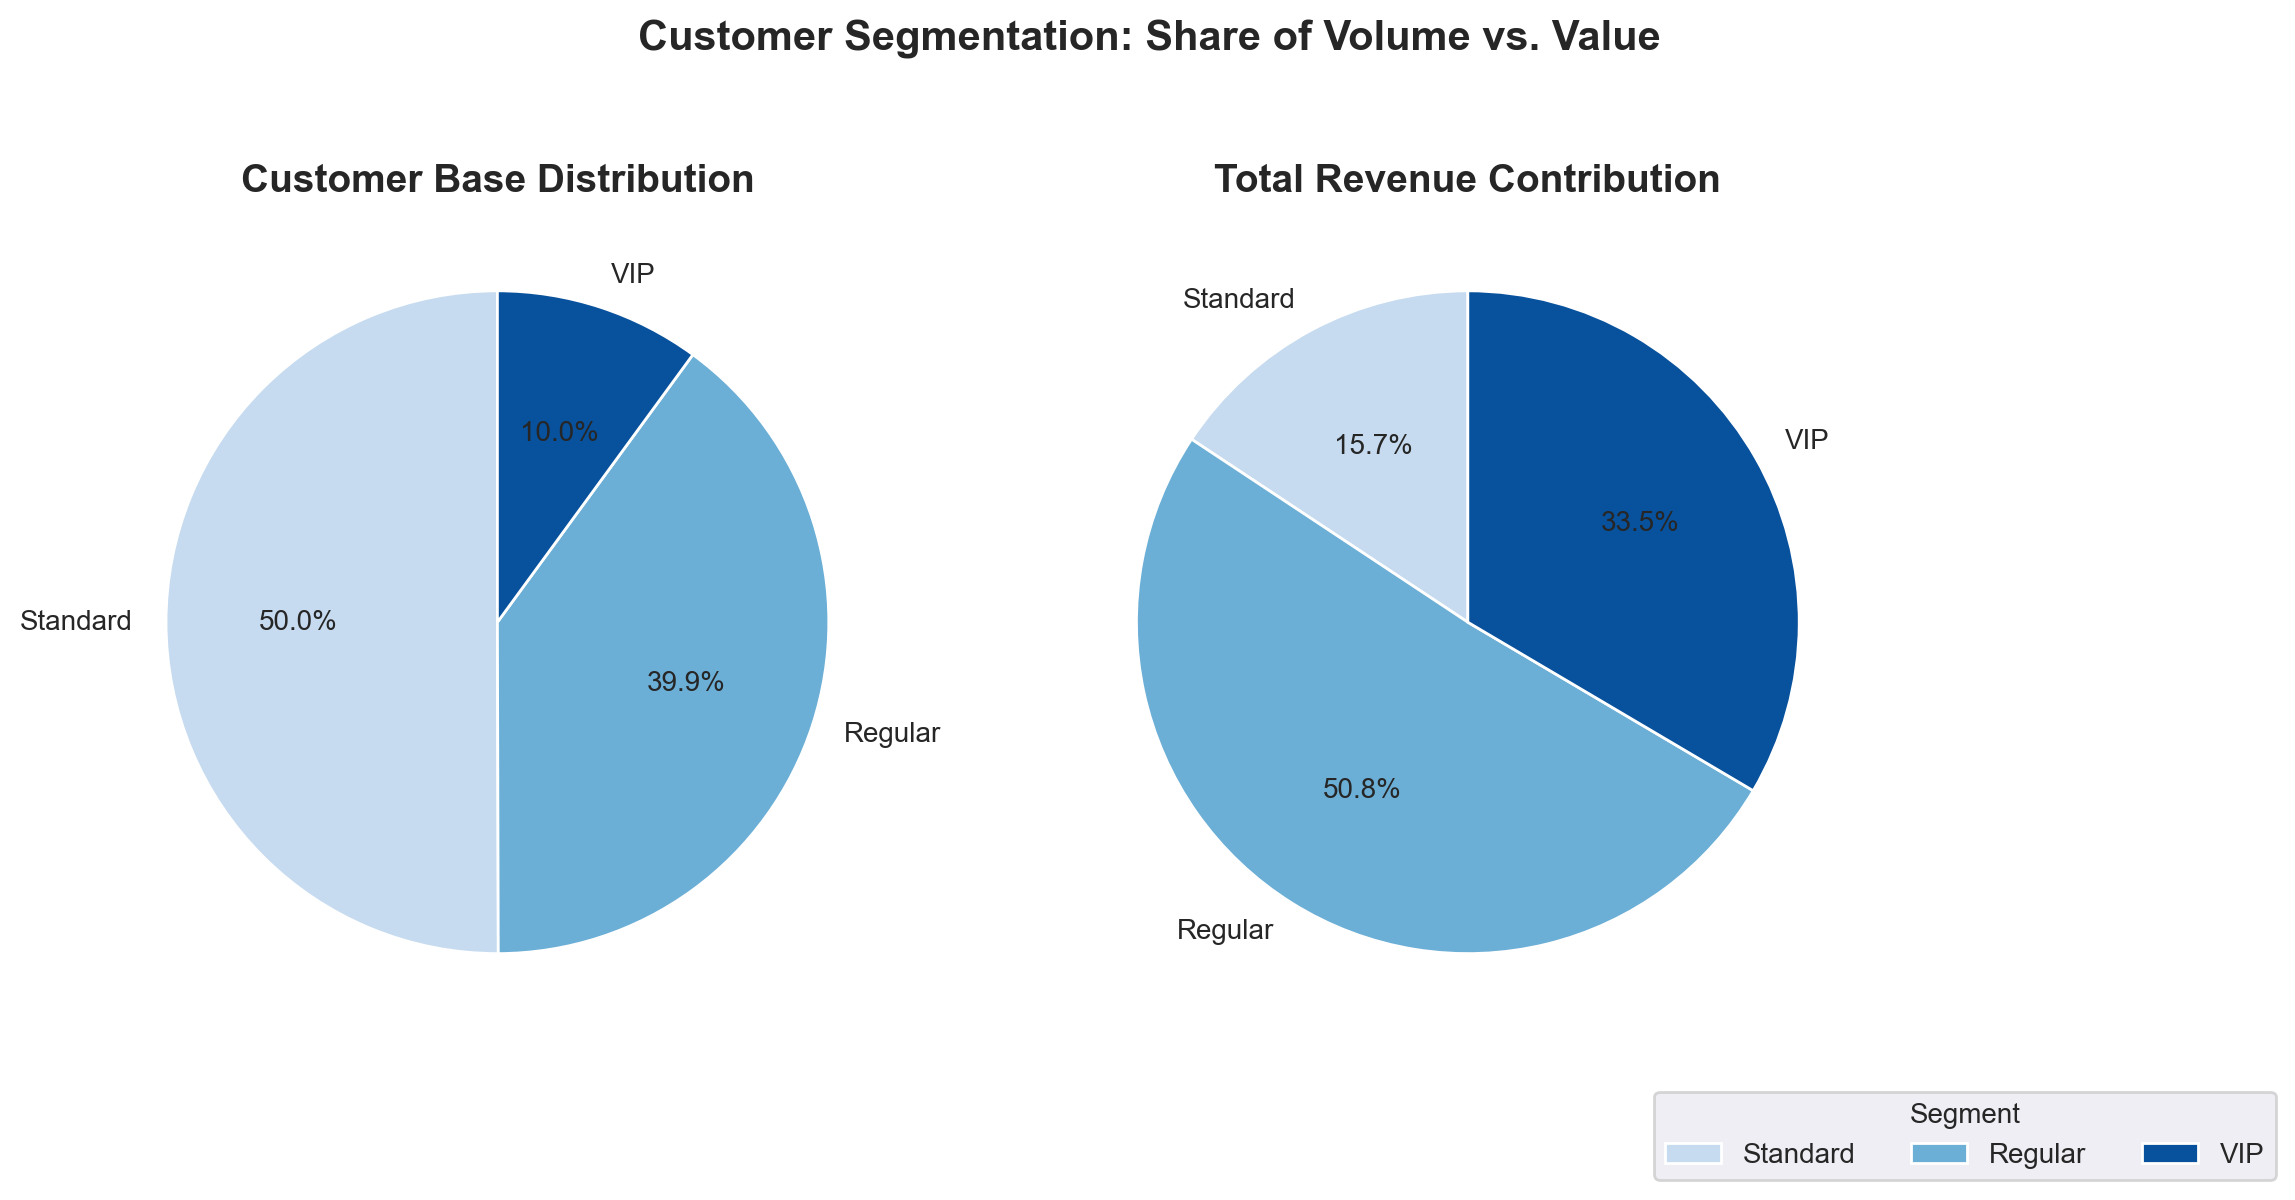

In [38]:
customer_data = df.groupby('customer_id', as_index = False).agg(total_spend = ('total_price', 'sum'))

customer_data['customer_class'] = pd.qcut(customer_data['total_spend'], q = [0.0, 0.5, 0.9, 1.0], 
                    labels = ['Standard', 'Regular', 'VIP'])

customer_class_data = customer_data.groupby('customer_class', observed = True, as_index = False).agg(
    total_revenue = ('total_spend', 'sum'), customer_count = ('customer_id', 'count'))

slice_colors = ['#c6dbef', '#6baed6', '#08519c']

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 6), dpi = 200)

wedges, _, _ = ax[0].pie(customer_class_data['customer_count'], labels = customer_class_data['customer_class'],
          autopct = '%1.1f%%', startangle = 90, colors = slice_colors, wedgeprops = {'edgecolor' : 'white'})
style_axis(ax[0], None, None, 'Customer Base Distribution')

ax[1].pie(customer_class_data['total_revenue'], labels = customer_class_data['customer_class'],
          autopct = '%1.1f%%', startangle = 90, colors = slice_colors, wedgeprops = {'edgecolor' : 'white'})
style_axis(ax[1], None, None, "Total Revenue Contribution")

for sub_ax in ax: 
    sub_ax.title.set_y(1.05)

plt.legend(
    wedges, customer_class_data['customer_class'],
    title = 'Segment', loc = 'upper center', ncol = 3, frameon = True, bbox_to_anchor = (1.1, -0.05))
plt.suptitle("Customer Segmentation: Share of Volume vs. Value", fontsize = 15, fontweight = 'bold', 
             y = 1.02)
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.savefig(fig_path + 'q5_customer_vs_revenue_share.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**Conclusion:** Although VIP customers represent only the top 10% of the customer
base, they contribute approximately one-third of total revenue. In contrast,
half of all customers generate less than one-sixth of revenue. These findings
highlight customer retention among high-value customers as a key business
priority alongside customer acquisition.

--- 

## Business Question 6 — What caused the June 2024 sales rebound?

Monthly revenue increased sharply in June 2024. Before recommending any
business action, we need to understand whether the recovery reflects broad
improvement across the business or is driven by a single product category.

**Hypothesis:** The June rebound is primarily driven by Electronics rather than
balanced growth across all categories.

**Evidence:** Compare category-level monthly revenue around the recovery period
(April–June 2024) to identify which categories contributed most to the increase.

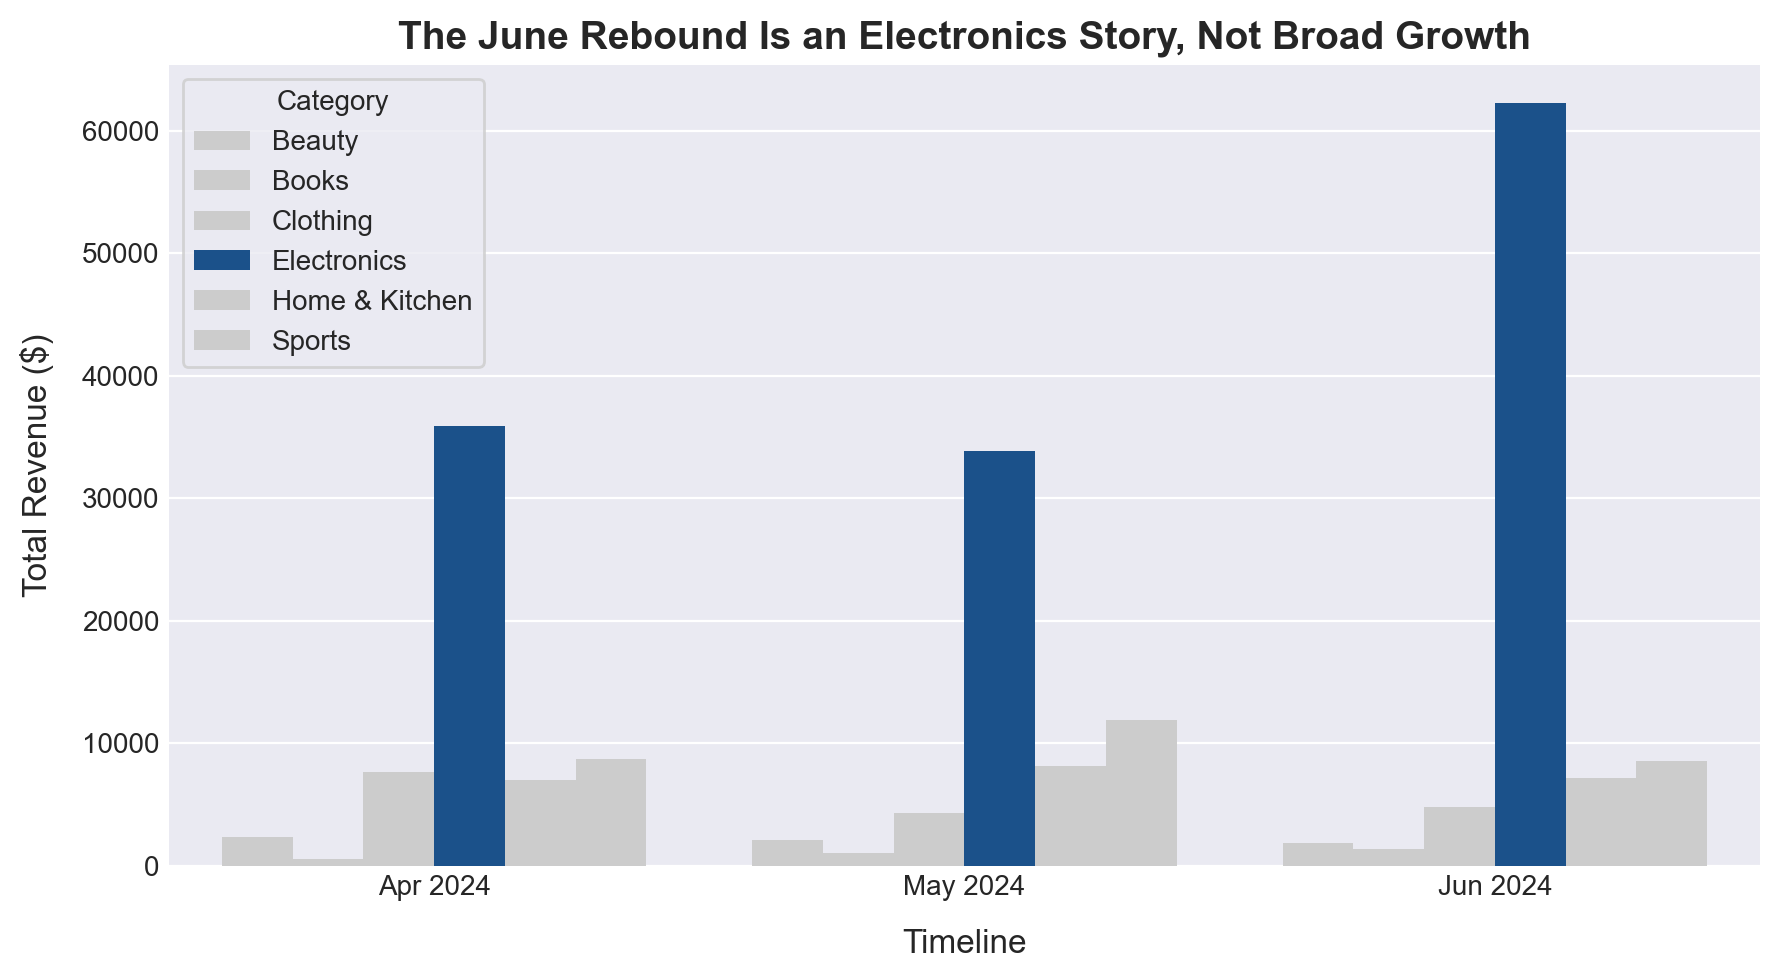

In [54]:
df['order_Y-M'] = df['order_date'].dt.to_period('M').dt.to_timestamp()
plot_data = df[df['order_Y-M'].isin(pd.to_datetime(["2024-04-01", "2024-05-01", "2024-06-01"]))]

plot_data = plot_data.groupby(['order_Y-M', 'category'], as_index = False).agg(
    order_count = ('order_id', 'count'), total_revenue = ('total_price', 'sum'))

plot_data['order_Y-M'] = plot_data['order_Y-M'].dt.strftime('%b %Y')

palette = {c: '#cccccc' for c in plot_data['category'].unique()}
palette['Electronics'] = '#08519c'

fig, ax = plt.subplots(figsize = (9, 5), dpi = 200)

sns.barplot(data = plot_data, x = 'order_Y-M', y = 'total_revenue', hue = 'category',
            ax = ax, palette = palette, order = ['Apr 2024', 'May 2024', 'Jun 2024'])

style_axis(ax, 'Timeline', 'Total Revenue ($)', 'The June Rebound Is an Electronics Story, Not Broad Growth')
ax.xaxis.labelpad = 10
ax.yaxis.labelpad = 10
ax.title.set_y(1.05)


ax.legend(title = 'Category', loc = 'upper left', frameon = True)
plt.tight_layout()
plt.savefig(fig_path + 'q6_june_rebound_decomposition.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**Conclusion:** June's sales recovery was driven primarily by Electronics. While
most categories showed only modest month-to-month fluctuations, Electronics
experienced a sharp increase in both order volume (31 → 55 orders) and revenue
($33.8k → $62.3k). The recovery therefore reflects category-specific demand
rather than a broad improvement across the business.